Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

Step 2: Load Training and Testing Datasets

In [2]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (66587, 49)
Test Shape: (16647, 48)


Step 3: Initial Data Exploration

In [3]:
train_df.head()

,index,encounter_id,patient_id,race,gender,age,weight,time_in_hospital,medical_specialty,num_lab_procedures,...,X19,X20,X21,X22,X23,X24,X25,change,diabetesMed,readmitted
0,69375,197029140,51521940,Hispanic,Male,[80-90),?,4,Emergency/Trauma,39,...,No,No,No,No,No,No,No,No,Yes,1
1,57272,163571946,92631357,Caucasian,Male,[60-70),?,3,Emergency/Trauma,34,...,No,No,No,No,No,No,No,No,No,0
2,82347,256497366,30023982,Caucasian,Female,[50-60),?,6,Nephrology,50,...,No,Down,No,No,No,No,No,Ch,Yes,1
3,89608,289891212,93606021,AfricanAmerican,Female,[70-80),?,5,?,63,...,No,Down,No,No,No,No,No,Ch,Yes,1
4,24091,81873900,23464296,Caucasian,Male,[70-80),?,9,Psychiatry,17,...,No,No,No,No,No,No,No,No,No,1


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66587 entries, 0 to 66586
Data columns (total 49 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               66587 non-null  int64  
 1   encounter_id        66587 non-null  int64  
 2   patient_id          66587 non-null  int64  
 3   race                66587 non-null  object 
 4   gender              66587 non-null  object 
 5   age                 66587 non-null  object 
 6   weight              66587 non-null  object 
 7   time_in_hospital    66587 non-null  int64  
 8   medical_specialty   66587 non-null  object 
 9   num_lab_procedures  66587 non-null  int64  
 10  num_procedures      66587 non-null  int64  
 11  num_medications     66587 non-null  int64  
 12  number_outpatient   66587 non-null  int64  
 13  number_emergency    66587 non-null  int64  
 14  number_inpatient    66587 non-null  int64  
 15  diag_1              66587 non-null  object 
 16  diag

In [5]:
train_df.describe()

,index,encounter_id,patient_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_5,number_diagnoses,readmitted
count,66587.000000,6.658700e+04,6.658700e+04,66587.000000,66587.000000,66587.000000,66587.000000,66587.000000,66587.000000,66587.000000,66587.000000,66587.000000,66587.000000
mean,50903.474282,1.653153e+08,5.422970e+07,4.397510,43.115533,1.331521,16.028744,0.365672,0.200460,0.637602,49.703387,7.424948,0.462012
std,29480.255515,1.030035e+08,3.878819e+07,2.980995,19.630417,1.705746,8.125304,1.221861,0.905503,1.255487,28.864879,1.933061,0.498559
min,0.000000,1.573800e+04,1.350000e+02,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000283,1.000000,0.000000
25%,25166.500000,8.440328e+07,2.338646e+07,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,24.622056,6.000000,0.000000
50%,51129.000000,1.528504e+08,4.526103e+07,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,49.508499,8.000000,0.000000
75%,76380.000000,2.305049e+08,8.727185e+07,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,74.637294,9.000000,1.000000
max,101765.000000,4.438672e+08,1.893494e+08,14.000000,129.000000,6.000000,81.000000,39.000000,63.000000,19.000000,99.995810,16.000000,1.000000


In [6]:
train_df.isnull().sum()

index                     0
encounter_id              0
patient_id                0
race                      0
gender                    0
age                       0
weight                    0
time_in_hospital          0
medical_specialty         0
num_lab_procedures        0
num_procedures            0
num_medications           0
number_outpatient         0
number_emergency          0
number_inpatient          0
diag_1                    0
diag_2                    0
diag_3                    0
diag_4                    0
diag_5                    0
number_diagnoses          0
X1                    63104
X2                    55451
X3                        0
X4                        0
X5                        0
X6                        0
X7                        0
X8                        0
X9                        0
X10                       0
X11                       0
X12                       0
X13                       0
X14                       0
X15                 

Step 4: Remove Duplicate Records

In [7]:
train_df.drop_duplicates(inplace=True)

print("Updated Shape:", train_df.shape)

Updated Shape: (48911, 49)


Step 5: Separate Features and Target Variable

In [8]:
target = "readmitted"

X_train = train_df.drop(target, axis=1)
y_train = train_df[target]

X_test = test_df.copy()

Step 6: Combine Train and Test Data

In [9]:
combined = pd.concat(
    [X_train, X_test],
    axis=0,
    ignore_index=True
)

print(combined.shape)

(65558, 48)


Step 7: Handle Missing Values

In [10]:
#Numerical Columns
num_cols = combined.select_dtypes(
    include=np.number
).columns

num_imputer = SimpleImputer(
    strategy="median"
)

combined[num_cols] = num_imputer.fit_transform(
    combined[num_cols]
)

In [11]:
#Categorical Columns
cat_cols = combined.select_dtypes(
    include="object"
).columns

cat_imputer = SimpleImputer(
    strategy="most_frequent"
)

combined[cat_cols] = cat_imputer.fit_transform(
    combined[cat_cols]
)

Step 8: Remove Unnecessary Columns

In [12]:
combined.drop(
    columns=["encounter_id", "patient_id"],
    errors="ignore",
    inplace=True
)

Step 9: Exploratory Data Analysis

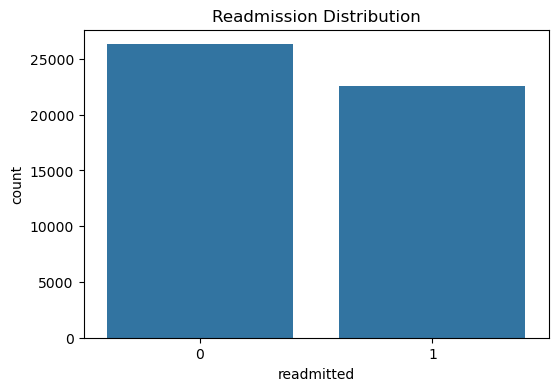

In [13]:
#Target Distribution
plt.figure(figsize=(6,4))

sns.countplot(
    x="readmitted",
    data=train_df
)

plt.title("Readmission Distribution")
plt.show()

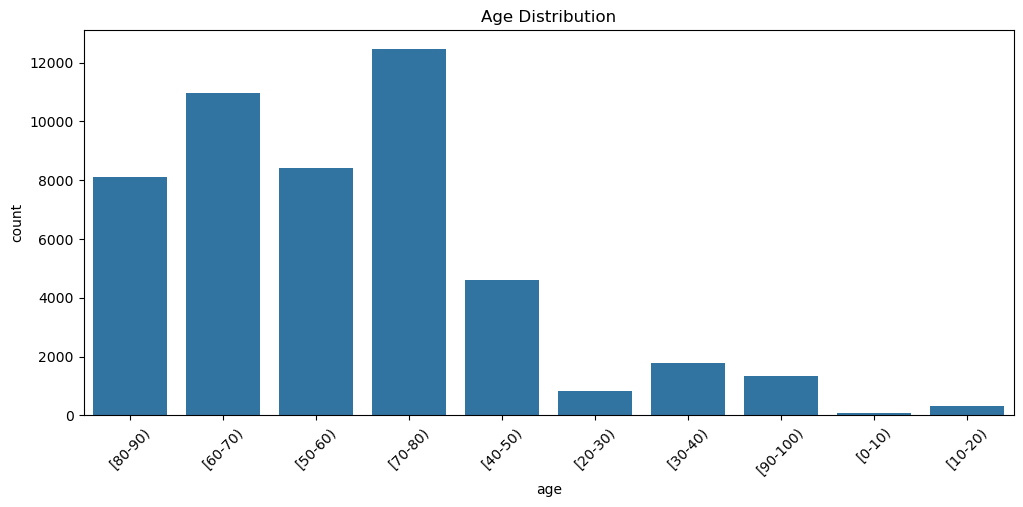

In [14]:
#Age Distribution
plt.figure(figsize=(12,5))

sns.countplot(
    x="age",
    data=train_df
)

plt.xticks(rotation=45)
plt.title("Age Distribution")
plt.show()

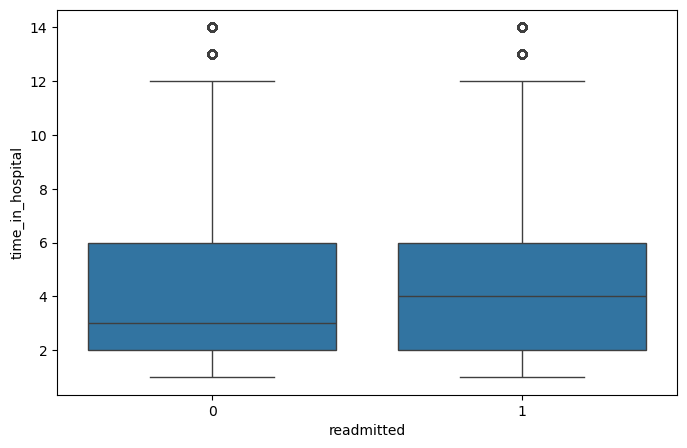

In [15]:
#Time in Hospital vs Readmission
plt.figure(figsize=(8,5))

sns.boxplot(
    x="readmitted",
    y="time_in_hospital",
    data=train_df
)

plt.show()

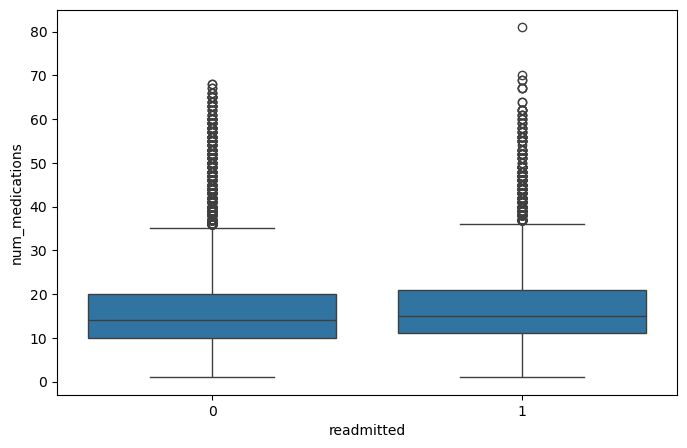

In [16]:
#Number of Medications vs Readmission
plt.figure(figsize=(8,5))

sns.boxplot(
    x="readmitted",
    y="num_medications",
    data=train_df
)

plt.show()

Step 10: Encode Categorical Features

In [17]:
encoder = LabelEncoder()

for col in combined.select_dtypes(
        include="object").columns:

    combined[col] = encoder.fit_transform(
        combined[col].astype(str)
    )

Step 11: Split Combined Data Back

In [18]:
X_train_processed = combined.iloc[
    :len(X_train)
]

X_test_processed = combined.iloc[
    len(X_train):
]

Step 12: Create Validation Dataset

In [19]:
X_train_final, X_valid, y_train_final, y_valid = train_test_split(
    X_train_processed,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

Step 13: Train Logistic Regression Model

In [20]:
lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train_final,
    y_train_final
)

valid_predictions = lr_model.predict(
    X_valid
)

Step 14: Evaluate Logistic Regression

In [21]:
print(
    "Accuracy:",
    accuracy_score(
        y_valid,
        valid_predictions
    )
)

print(
    "Precision:",
    precision_score(
        y_valid,
        valid_predictions
    )
)

print(
    "Recall:",
    recall_score(
        y_valid,
        valid_predictions
    )
)

print(
    "F1 Score:",
    f1_score(
        y_valid,
        valid_predictions
    )
)

Accuracy: 0.5983849534907493
Precision: 0.5617837049385288
Recall: 0.5961963732861566
F1 Score: 0.5784787040017165


In [22]:
print(
    classification_report(
        y_valid,
        valid_predictions
    )
)

              precision    recall  f1-score   support

           0       0.63      0.60      0.62      5261
           1       0.56      0.60      0.58      4522

    accuracy                           0.60      9783
   macro avg       0.60      0.60      0.60      9783
weighted avg       0.60      0.60      0.60      9783



Step 15: Logistic Regression Confusion Matrix

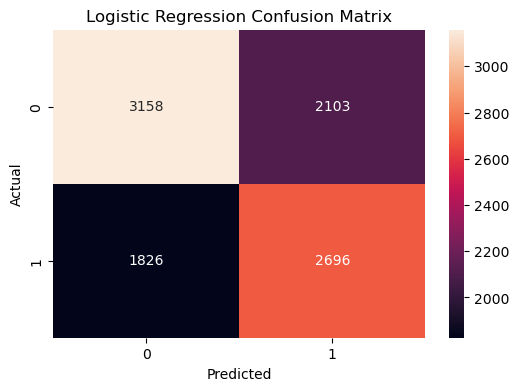

In [23]:
cm = confusion_matrix(
    y_valid,
    valid_predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Step 16: Hyperparameter Tuning for Logistic Regression

In [24]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

grid_search = GridSearchCV(
    LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ),
    param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

grid_search.fit(
    X_train_final,
    y_train_final
)

best_lr = grid_search.best_estimator_

print(
    grid_search.best_params_
)

{'C': 1, 'solver': 'lbfgs'}


Step 17: Train Random Forest Model

In [25]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_final,
    y_train_final
)

rf_predictions = rf_model.predict(
    X_valid
)

Step 18: Evaluate Random Forest

In [26]:
print(
    "Accuracy:",
    accuracy_score(
        y_valid,
        rf_predictions
    )
)

print(
    "Precision:",
    precision_score(
        y_valid,
        rf_predictions
    )
)

print(
    "Recall:",
    recall_score(
        y_valid,
        rf_predictions
    )
)

print(
    "F1 Score:",
    f1_score(
        y_valid,
        rf_predictions
    )
)

Accuracy: 0.6235306143309823
Precision: 0.6241491565551939
Recall: 0.46638655462184875
F1 Score: 0.5338564738640679


In [27]:
print(
    classification_report(
        y_valid,
        rf_predictions
    )
)

              precision    recall  f1-score   support

           0       0.62      0.76      0.68      5261
           1       0.62      0.47      0.53      4522

    accuracy                           0.62      9783
   macro avg       0.62      0.61      0.61      9783
weighted avg       0.62      0.62      0.61      9783



Step 19: Random Forest Confusion Matrix

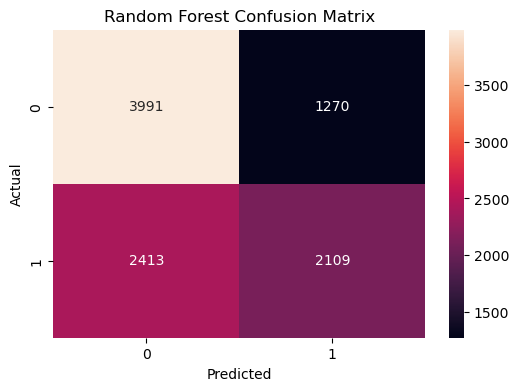

In [28]:
rf_cm = confusion_matrix(
    y_valid,
    rf_predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Step 20: Random Forest Hyperparameter Tuning

In [29]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    rf_param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

rf_grid.fit(
    X_train_final,
    y_train_final
)

best_rf = rf_grid.best_estimator_

print(
    rf_grid.best_params_
)

{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


Step 21: Model Comparison

In [30]:
lr_f1 = f1_score(
    y_valid,
    valid_predictions
)

rf_f1 = f1_score(
    y_valid,
    rf_predictions
)

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "F1 Score": [
        lr_f1,
        rf_f1
    ]
})

comparison

,Model,F1 Score
0,Logistic Regression,0.578479
1,Random Forest,0.533856


Step 22: Select Best Model

In [31]:
if rf_f1 > lr_f1:
    final_model = best_rf
else:
    final_model = best_lr

final_model.fit(
    X_train_processed,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Step 23: Predict Test Dataset

In [32]:
test_predictions = final_model.predict(
    X_test_processed
)

Step 24: Create Submission File

In [33]:
submission = pd.DataFrame({
    "readmitted": test_predictions
})

submission.to_csv(
    "submission.csv",
    index=False
)

submission.head()

,readmitted
0,1
1,0
2,1
3,0
4,0


Step 25: Feature Importance

In [34]:
if hasattr(
    final_model,
    "feature_importances_"
):

    importance = pd.DataFrame({
        "Feature":
        X_train_processed.columns,

        "Importance":
        final_model.feature_importances_
    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

else:

    importance = pd.DataFrame({
        "Feature":
        X_train_processed.columns,

        "Coefficient":
        final_model.coef_[0]
    })

    importance["Abs_Coefficient"] = abs(
        importance["Coefficient"]
    )

    importance = importance.sort_values(
        by="Abs_Coefficient",
        ascending=False
    )

importance.head(20)

,Feature,Coefficient,Abs_Coefficient
12,number_inpatient,0.325351,0.325351
11,number_emergency,0.127627,0.127627
10,number_outpatient,0.113714,0.113714
18,number_diagnoses,0.103889,0.103889
8,num_procedures,-0.101192,0.101192
3,age,-0.038992,0.038992
4,weight,0.038937,0.038937
44,change,-0.036733,0.036733
21,X3,-0.032319,0.032319
45,diabetesMed,0.028024,0.028024


Step 26: Feature Importance Visualization

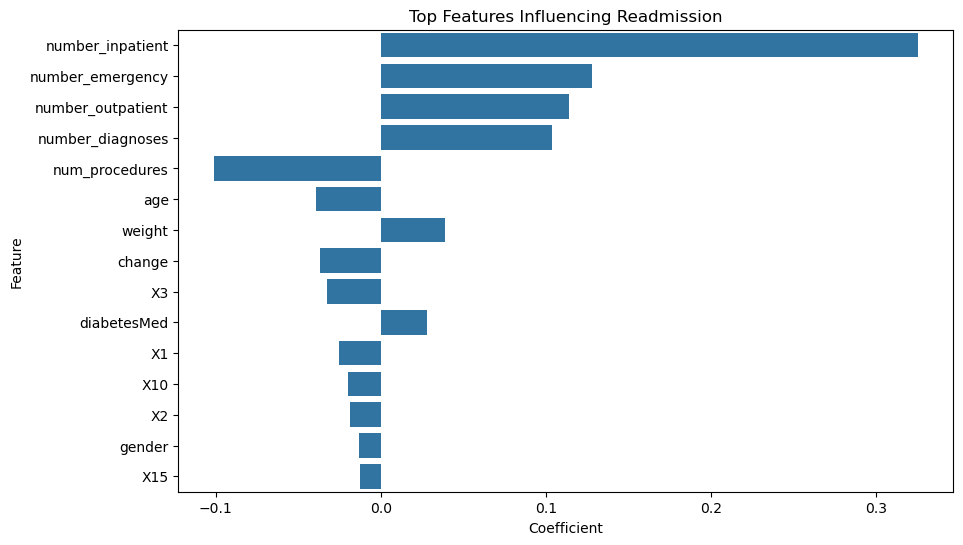

In [35]:
top_features = importance.head(15)

plt.figure(figsize=(10,6))

if "Importance" in top_features.columns:

    sns.barplot(
        data=top_features,
        x="Importance",
        y="Feature"
    )

else:

    sns.barplot(
        data=top_features,
        x="Coefficient",
        y="Feature"
    )

plt.title(
    "Top Features Influencing Readmission"
)

plt.show()